#  Toyota Stock Price Prediction — LSTM

**Dataset:** `Toyota_Stock_Prices_1980_2026.csv`  
**Task:** Time Series Forecasting  
**Model:** Long Short-Term Memory (LSTM)

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
# Install torch jika belum ada
try:
    import torch
    print('PyTorch sudah terinstall, versi:', torch.__version__)
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torch', '--index-url',
                    'https://download.pytorch.org/whl/cpu', '-q'])
    import torch
    print('PyTorch berhasil diinstall, versi:', torch.__version__)

PyTorch sudah terinstall, versi: 2.10.0+cu128


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deteksi device dengan fallback ke CPU jika CUDA tidak benar-benar tersedia
try:
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        torch.zeros(1).to(DEVICE)  # test apakah CUDA benar-benar berfungsi
    else:
        DEVICE = torch.device('cpu')
except Exception:
    DEVICE = torch.device('cpu')

print('Libraries loaded')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')

Libraries loaded
PyTorch version: 2.10.0+cu128
Device: cuda


---
## 1.  Cara Melihat Tipe Data

In [3]:
df = pd.read_csv('../Toyota_Stock_Prices_1980_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f'Shape: {df.shape}')
df.info()
df.head()

Shape: (11508, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11508 non-null  datetime64[ns]
 1   Close   11508 non-null  float64       
 2   High    11508 non-null  float64       
 3   Low     11508 non-null  float64       
 4   Open    11508 non-null  float64       
 5   Volume  11508 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 539.6 KB


,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


---
## 2.  Dataset Bisa Digunakan Untuk Apa

**LSTM cocok untuk stock price karena:**
- Menangkap dependensi jangka panjang (long-term dependencies)
- Cell state menyimpan informasi dari ratusan timestep sebelumnya
- Cocok untuk sequence data dengan pola temporal kompleks

**Format input LSTM:** 3D tensor `(samples, timesteps, features)`

Contoh: window=60 hari, 1 fitur (Close) → shape `(N, 60, 1)`

In [4]:
# Gunakan data mulai 2015
df_recent = df[df['Date'] >= '2015-01-01'].copy()
close = df_recent['Close'].values.reshape(-1, 1)

# Normalisasi ke [0, 1] — LSTM bekerja lebih baik dengan data ternormalisasi
scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(close)

print(f'Total data: {len(close_scaled)}')
print(f'Range setelah scaling: [{close_scaled.min():.2f}, {close_scaled.max():.2f}]')

Total data: 2786
Range setelah scaling: [0.00, 1.00]


In [5]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

WINDOW = 60  # Lihat 60 hari ke belakang untuk prediksi hari berikutnya

# Split 80/20 kronologis
n = len(close_scaled)
split = int(n * 0.8)
train_data = close_scaled[:split]
test_data  = close_scaled[split - WINDOW:]  # Ambil WINDOW hari sebelum test untuk warmup

X_train, y_train = create_sequences(train_data, WINDOW)
X_test,  y_test  = create_sequences(test_data,  WINDOW)

# Reshape untuk LSTM: (samples, timesteps, features)
X_train = X_train.reshape(-1, WINDOW, 1)
X_test  = X_test.reshape(-1, WINDOW, 1)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

# Buat PyTorch Tensors dan DataLoader
X_tr_t = torch.tensor(X_train)
y_tr_t = torch.tensor(y_train).unsqueeze(1)
X_te_t = torch.tensor(X_test)
y_te_t = torch.tensor(y_test).unsqueeze(1)

# Validation split (10% akhir dari training)
val_split = int(len(X_tr_t) * 0.9)
X_val_t   = X_tr_t[val_split:]
y_val_t   = y_tr_t[val_split:]
X_tr_only = X_tr_t[:val_split]
y_tr_only = y_tr_t[:val_split]

train_ds     = TensorDataset(X_tr_only, y_tr_only)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)  # jangan shuffle untuk time series
print('DataLoader siap')

X_train shape: (2168, 60, 1)
X_test shape : (558, 60, 1)
DataLoader siap


---
## 3. Arsitektur LSTM (PyTorch)

LSTM menggunakan **gate mechanism**:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$ (Forget Gate)

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$ (Input Gate)

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$ (Output Gate)

**Keunggulan LSTM:**
- Mengatasi vanishing gradient
- Menangkap pola jangka pendek DAN jangka panjang
- Sangat populer untuk financial forecasting

**PyTorch vs TensorFlow:**
- PyTorch menggunakan `define-by-run` (dynamic graph) — lebih intuitif untuk debugging
- Training loop ditulis manual → kontrol penuh atas setiap step

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # Ambil output dari timestep terakhir saja
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out)


model = LSTMModel(input_size=1, hidden_size=64, n_layers=2, dropout=0.2).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 52,545


---
## 4. Parameter Yang Bisa Diubah / Disetel

| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| `WINDOW` | 30–90 | Seberapa jauh melihat ke belakang |
| `hidden_size` | 32–256 | Ukuran hidden state LSTM |
| `n_layers` | 1–4 | Kedalaman LSTM |
| `dropout` | 0.1–0.5 | Regularisasi (hanya aktif jika n_layers > 1) |
| `learning_rate` | 1e-4 – 1e-2 | Kecepatan belajar Adam |
| `batch_size` | 16–128 | Ukuran mini batch |
| `N_EPOCHS` | 50–200 | Jumlah epoch maksimum |
| `PATIENCE` | 10–30 | Early stopping patience |

In [7]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler  = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

N_EPOCHS  = 100
PATIENCE  = 15
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
train_losses, val_losses = [], []

print('Memulai training...')
for epoch in range(1, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_tr_only)

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t.to(DEVICE))
        val_loss = criterion(val_pred, y_val_t.to(DEVICE)).item()
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f}')

# Restore best weights
model.load_state_dict(best_weights)
print('Training selesai!')

Memulai training...
Epoch  10 | Train Loss: 0.019618 | Val Loss: 0.024182
Epoch  20 | Train Loss: 0.013006 | Val Loss: 0.044765
Early stopping at epoch 26
Training selesai!


---
## 5.  Evaluasi Yang Dipakai

In [8]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_te_t.to(DEVICE)).cpu().numpy()

pred   = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae  = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
dir_acc = np.mean(
    np.sign(np.diff(actual.flatten())) == np.sign(np.diff(pred.flatten()))
) * 100

print('=' * 50)
print('EVALUASI LSTM (PyTorch)')
print('=' * 50)
print(f'MAE            : {mae:.4f}')
print(f'RMSE           : {rmse:.4f}')
print(f'MAPE           : {mape:.2f}%')
print(f'Directional Acc: {dir_acc:.2f}%')

EVALUASI LSTM (PyTorch)
MAE            : 39.1133
RMSE           : 42.6506
MAPE           : 19.74%
Directional Acc: 49.73%


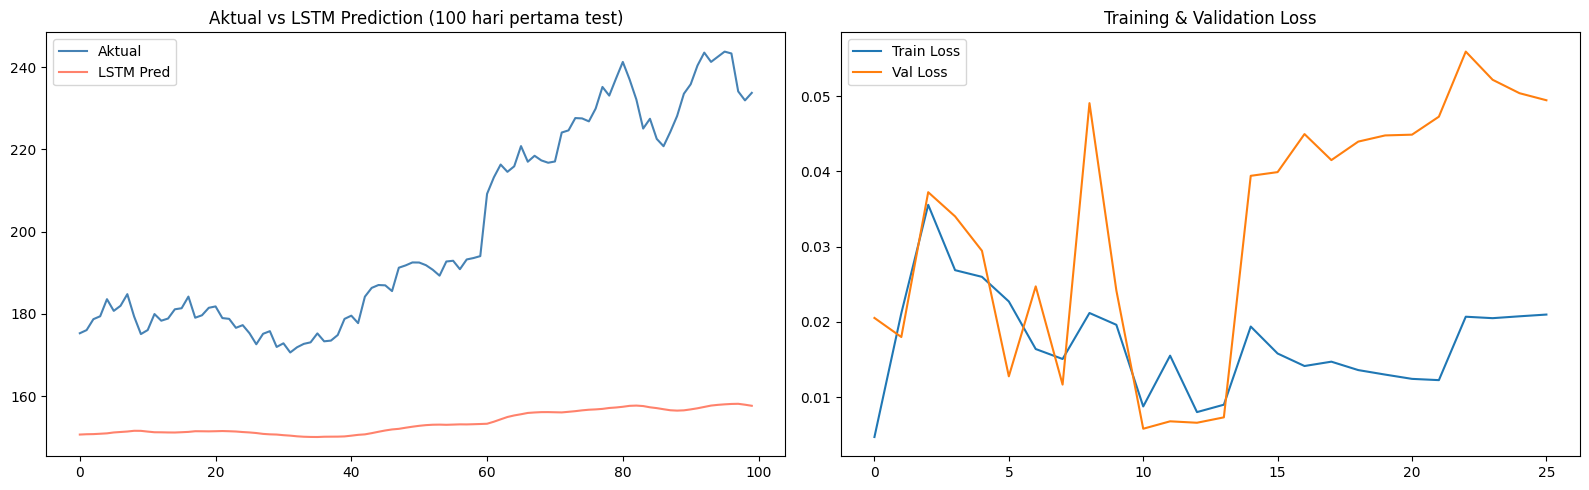

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(actual[:100], label='Aktual', color='steelblue')
axes[0].plot(pred[:100],   label='LSTM Pred', color='tomato', alpha=0.8)
axes[0].set_title('Aktual vs LSTM Prediction (100 hari pertama test)')
axes[0].legend()

axes[1].plot(train_losses, label='Train Loss')
axes[1].plot(val_losses,   label='Val Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

| Metrik | Baik | Cukup | Buruk |
|--------|------|-------|-------|
| MAPE | < 3% | 3–8% | > 8% |
| Directional Acc | > 55% | 50–55% | < 50% |

### Tanda Overfitting:
- Train loss jauh lebih rendah dari val loss
- **Solusi:** Tambah Dropout, kurangi jumlah neuron, pakai L2 regularization

### Tanda Underfitting:
- Training loss tidak turun, prediksi terlalu smooth
- **Solusi:** Tambah layer, tambah neuron, naikkan epochs

---
## 7. Cara Mengoptimasi Model

### Strategi Optimasi:

1. **Ubah WINDOW size** — coba 30, 60, 90 hari
2. **Tambah multivariate features** — tambah High, Low, Volume sebagai input tambahan
3. **Feature engineering** — tambah RSI, Moving Average, Bollinger Bands
4. **Bidirectional LSTM** — membaca sequence dari dua arah

```python
# Bidirectional LSTM di PyTorch:
class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2 * 64, 1)  # output size = 2 * hidden_size (karena bidirectional)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
```

In [10]:
# Test dengan window size berbeda (versi cepat, 20 epochs saja)
results = {}
for win in [30, 60, 90]:
    X_tr_w, y_tr_w = create_sequences(train_data, win)
    test_d_w = close_scaled[split - win:]
    X_te_w, y_te_w = create_sequences(test_d_w, win)
    X_tr_w = X_tr_w.reshape(-1, win, 1)
    X_te_w = X_te_w.reshape(-1, win, 1)

    m = LSTMModel(input_size=1, hidden_size=32, n_layers=1).to(DEVICE)
    opt  = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()

    Xtr_t = torch.tensor(X_tr_w)
    ytr_t = torch.tensor(y_tr_w).unsqueeze(1)
    Xte_t = torch.tensor(X_te_w)
    ds = TensorDataset(Xtr_t, ytr_t)
    dl = DataLoader(ds, batch_size=32, shuffle=False)

    m.train()
    for _ in range(20):
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(m(xb), yb).backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        p = m(Xte_t.to(DEVICE)).cpu().numpy()
    p_real = scaler.inverse_transform(p)
    a_real = scaler.inverse_transform(y_te_w.reshape(-1, 1))
    results[win] = np.sqrt(mean_squared_error(a_real, p_real))

print('RMSE per window size (quick test — 20 epochs):')
for k, v in results.items():
    print(f'  Window={k}: RMSE={v:.4f}')

RMSE per window size (quick test — 20 epochs):
  Window=30: RMSE=5.6218
  Window=60: RMSE=6.6991
  Window=90: RMSE=7.5175


---
## 8. Cara Menyimpan Model

PyTorch menyimpan dengan `torch.save()`. Ada 2 cara:
1. **State dict** (direkomendasikan) — hanya simpan bobot, lebih portabel
2. **Entire model** — simpan seluruh objek Python (kurang portabel)

Selalu simpan **konfigurasi model** bersama state dict agar bisa membuat ulang arsitektur saat loading.

In [11]:
os.makedirs('saved_models', exist_ok=True)

# Simpan model state dict + config (cara yang direkomendasikan di PyTorch)
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'input_size': 1,
        'hidden_size': 64,
        'n_layers': 2,
        'dropout': 0.2,
        'window': WINDOW
    },
    'train_losses': train_losses,
    'val_losses':   val_losses
}, 'saved_models/lstm_toyota.pth')

# Simpan scaler agar bisa inverse_transform saat inference
joblib.dump(scaler, 'saved_models/scaler_lstm.pkl')

print('LSTM model tersimpan di saved_models/lstm_toyota.pth')
size_kb = os.path.getsize('saved_models/lstm_toyota.pth') / 1024
print(f'Ukuran file: {size_kb:.1f} KB')

LSTM model tersimpan di saved_models/lstm_toyota.pth
Ukuran file: 209.3 KB


---
## 9.  Cara Menggunakan Model Hasil Training

Model dimuat (window=60)

Forecast Harga 30 Hari ke Depan:
  Hari 1: $156.64
  Hari 2: $154.82
  Hari 3: $153.05
  Hari 4: $151.49
  Hari 5: $150.16


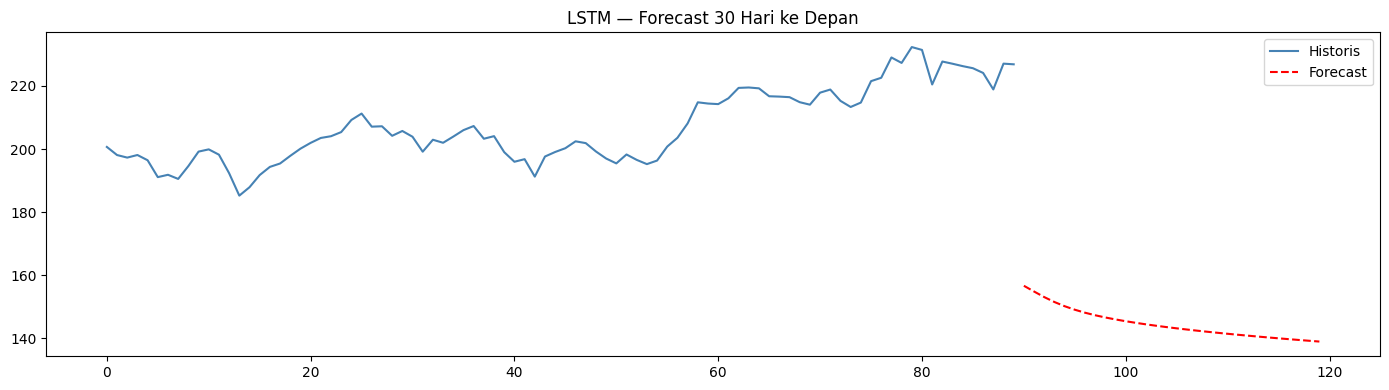

In [12]:
# Load model
checkpoint    = torch.load('saved_models/lstm_toyota.pth', map_location=DEVICE)
cfg           = checkpoint['config']
win           = cfg['window']
loaded_scaler = joblib.load('saved_models/scaler_lstm.pkl')

loaded_model = LSTMModel(
    input_size=cfg['input_size'],
    hidden_size=cfg['hidden_size'],
    n_layers=cfg['n_layers'],
    dropout=cfg['dropout']
).to(DEVICE)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print(f'Model dimuat (window={win})')

# Prediksi n hari ke depan secara iteratif
n_future = 30
last_seq  = loaded_scaler.transform(close[-win:])
seq       = list(last_seq.flatten())
future_preds = []

with torch.no_grad():
    for _ in range(n_future):
        inp = torch.tensor(
            np.array(seq[-win:], dtype=np.float32).reshape(1, win, 1)
        ).to(DEVICE)
        pred_val = loaded_model(inp).item()
        seq.append(pred_val)
        future_preds.append(pred_val)

future_preds_real = loaded_scaler.inverse_transform(
    np.array(future_preds, dtype=np.float32).reshape(-1, 1)
)

print(f'\nForecast Harga {n_future} Hari ke Depan:')
for i, p in enumerate(future_preds_real[:5]):
    print(f'  Hari {i+1}: ${p[0]:.2f}')

# Plot forecast
plt.figure(figsize=(14, 4))
hist = loaded_scaler.inverse_transform(close_scaled[-90:])
plt.plot(hist, label='Historis', color='steelblue')
start = len(hist)
plt.plot(range(start, start + n_future), future_preds_real, 'r--', label='Forecast')
plt.title(f'LSTM — Forecast {n_future} Hari ke Depan')
plt.legend()
plt.tight_layout()
plt.show()